# Results FCBG Connectome Registration

Visualisation of metabolite concentration maps (MRSI) overlaid on the T1w UNI-DEN background.


In [1]:
%run main.py
from utils import (
    img_info,
    plot_single_overlay,
    plot_support_mask,
    plot_coverage_grid,
    build_coverage_widget,
)

  [T1w] _t1_mp2rage_sag_pTx_20250307114538_10.nii  →  anat/sub-01_ses-01_acq-MPRcor_T1w.nii
  [T1w] _t1_mp2rage_sag_pTx_20250307114538_11.nii  →  anat/sub-01_ses-01_acq-UNIDEND_T1w.nii
  [T1w] _t1_mp2rage_sag_pTx_20250307114538_12.nii  →  anat/sub-01_ses-01_acq-MPRcorND_T1w.nii
  [T1w] _t1_mp2rage_sag_pTx_20250307114538_13.nii  →  anat/sub-01_ses-01_acq-MPRtraND_T1w.nii
  [T1w] _t1_mp2rage_sag_pTx_20250307114538_3.nii  →  anat/sub-01_ses-01_T1map.nii
  [T1w] _t1_mp2rage_sag_pTx_20250307114538_5.nii  →  anat/sub-01_ses-01_acq-UNI_UNIT1.nii
  [T1w] _t1_mp2rage_sag_pTx_20250307114538_6.nii  →  anat/sub-01_ses-01_acq-UNIDEN_T1w.nii
  [T1w] _t1_mp2rage_sag_pTx_20250307114538_7.nii  →  anat/sub-01_ses-01_inv-1_MP2RAGE.nii
  [T1w] _t1_mp2rage_sag_pTx_20250307114538_8.nii  →  anat/sub-01_ses-01_inv-2_MP2RAGE.nii
  [T1w] _t1_mp2rage_sag_pTx_20250307114538_9.nii  →  anat/sub-01_ses-01_acq-MPRtra_T1w.nii
  [MRS] sub-01: EIB_conc_reo.nii.gz  →  mrs/sub-01_ses-01_desc-EIB_mrsi.nii.gz
  [MRS] sub-01

## 1 – Sanity check: image shapes & voxel sizes

In [7]:
img_info(t1w_img,     "T1w UNI-DEN")
img_info(mrs_example, f"MRS – {mrs_files[0]}")

T1w UNI-DEN
  shape      : (224, 272, 288)
  voxel size : [0.8   0.799 0.799] mm
  dtype      : int16

MRS – sub-01_ses-01_acq-OrigRes_desc-2HG_mrsi.nii.gz
  shape      : (74, 74, 37)
  voxel size : [2.973 2.973 2.973] mm
  dtype      : float32



## 2 – Single metabolite overlay on T1w

`plot_single_overlay` canonicalizes orientations, resamples MRSI to T1 grid, and plots 3 orthogonal views.  
Change `METABOLITE` to any label available in `mrs_files`.

In [ ]:
METABOLITE = "NAA"   # ← change to any metabolite label (e.g. "Cr", "Glu", "GABA")
match = [f for f in mrs_files if f"desc-{METABOLITE}_" in f]
if not match:
    print(f"No file found for metabolite '{METABOLITE}'")
else:
    print(f"Showing: {match[0]}")
    plot_single_overlay(match[0], T1W_PATH, MRS_DIR, subj=SUBJ)


NameError: name 'np' is not defined

## 3 – Coverage check: do the MRSI maps cover the whole brain?

Overlay several metabolite maps on the T1w in a single figure  so we can directly compare spatial coverage across metabolites.

In [ ]:
COVERAGE_MAPS = [
    f"{SUBJ}_{SES}_acq-OrigRes_desc-NAA_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Cr_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Glu_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Ins_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-GABA_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-GluaddGln_mrsi.nii.gz",
]
plot_coverage_grid(COVERAGE_MAPS, MRS_DIR, T1W_PATH, subj=SUBJ)


NameError: name 'plt' is not defined

## 4 – Interactive viewer: pick any metabolite

Change `METABOLITE` below to any label (e.g. `"Cr"`, `"Glu"`, `"GABA"`, `"Ins"`) and re-run the cell.

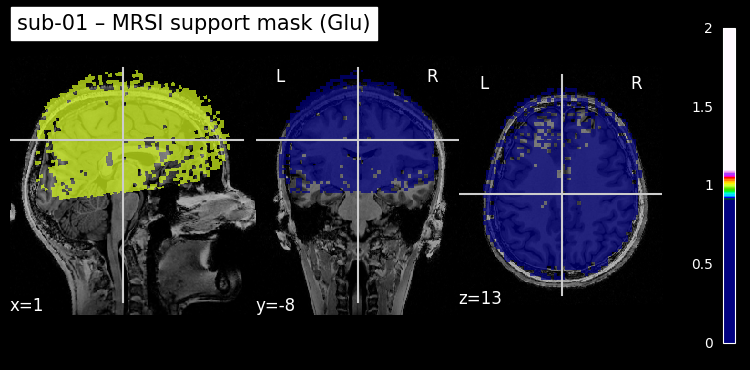

  Brain coverage: 14.1%


0.1414142215021152

In [5]:
plot_support_mask(
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Glu_mrsi.nii.gz",
    T1W_PATH, MRS_DIR, subj=SUBJ,
)

## 5 – Interactive multi-metabolite brain-coverage viewer

Use the checkboxes to pick any combination of metabolites.  
The selected maps are **summed** and overlaid on the T1w UNI-DEN background so you can compare spatial coverage at a glance.

In [6]:
from IPython.display import display
display(build_coverage_widget(MRS_DIR, T1W_PATH, subj=SUBJ))